# Tutorial 2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load data efficiently with calamine engine
flat_filepath = r'C:\Users\suggu\IITM\Acads\CE6018\data\FlatFiles\NGAsub_MegaFlatfile_RotD50_050_R211022_public.xlsx'

# Get all column names first
df_temp = pd.read_excel(flat_filepath, engine='openpyxl', nrows=0)
all_cols = df_temp.columns.tolist()

# Find all period columns (T columns)
period_cols = [col for col in all_cols if col.startswith('T') and col.endswith('S')]

# Define columns to load
selected_columns = [
    'Earthquake_Magnitude',
    'Rjb_km',
    'Vs30_Selected_for_Analysis_m_s',
    'Fault_Type',
    'PGA_g'
] + period_cols

print(f"Loading {len(selected_columns)} columns...")
df = pd.read_excel(flat_filepath, engine='openpyxl', usecols=selected_columns)
print(f"Loaded data shape: {df.shape}")

Loading 116 columns...
Loaded data shape: (71340, 116)


In [3]:
# Apply filters to remove outliers
print(f"Original shape: {df.shape}")

# Filter 1: Magnitude >= 4
df = df[df['Earthquake_Magnitude'] >= 4]
print(f"After M >= 4 filter: {df.shape}")

# Filter 2: Distance 0-500 km
df = df[(df['Rjb_km'] >= 0) & (df['Rjb_km'] <= 500)]
print(f"After distance filter: {df.shape}")

# Filter 3: Remove negative values in numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df = df[~(df[numeric_cols] < 0).any(axis=1)]
print(f"After negative value removal: {df.shape}")

# Reset index
df = df.reset_index(drop=True)
print(f"\nFinal cleaned data: {len(df)} earthquakes")

Original shape: (71340, 116)
After M >= 4 filter: (68473, 116)
After distance filter: (55395, 116)
After negative value removal: (54173, 116)

Final cleaned data: 54173 earthquakes


In [4]:
# Extract and sort periods
periods = []
for col in period_cols:
    period_str = col[1:-1].replace('pt', '.')
    periods.append(float(period_str))

sorted_indices = np.argsort(periods)
periods_sorted = np.array(periods)[sorted_indices]
period_cols_sorted = [period_cols[i] for i in sorted_indices]

print(f"Period range: {periods_sorted.min():.3f} to {periods_sorted.max():.3f} seconds")
print(f"Number of periods: {len(periods_sorted)}")

Period range: 0.010 to 20.000 seconds
Number of periods: 111


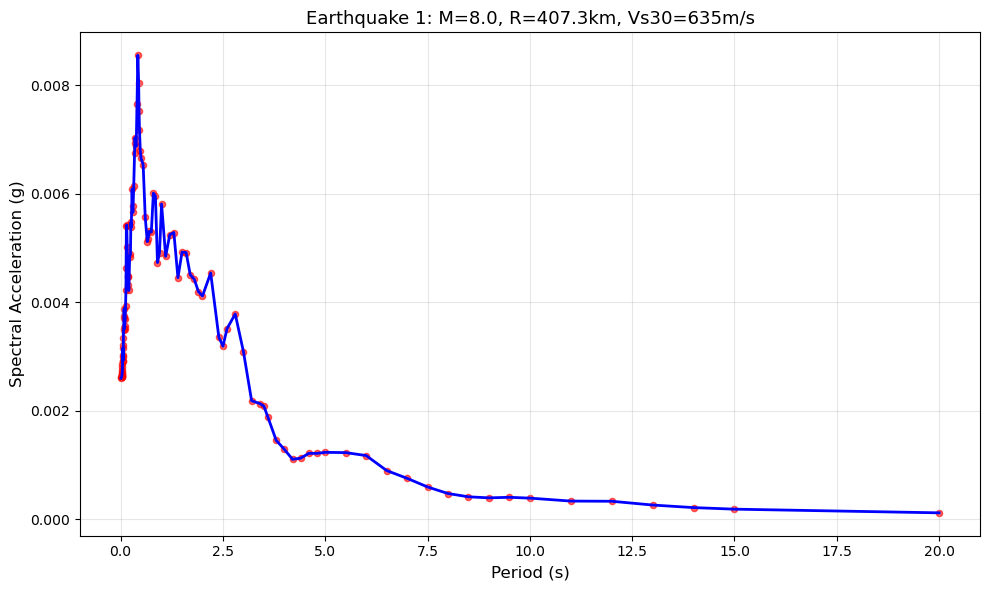

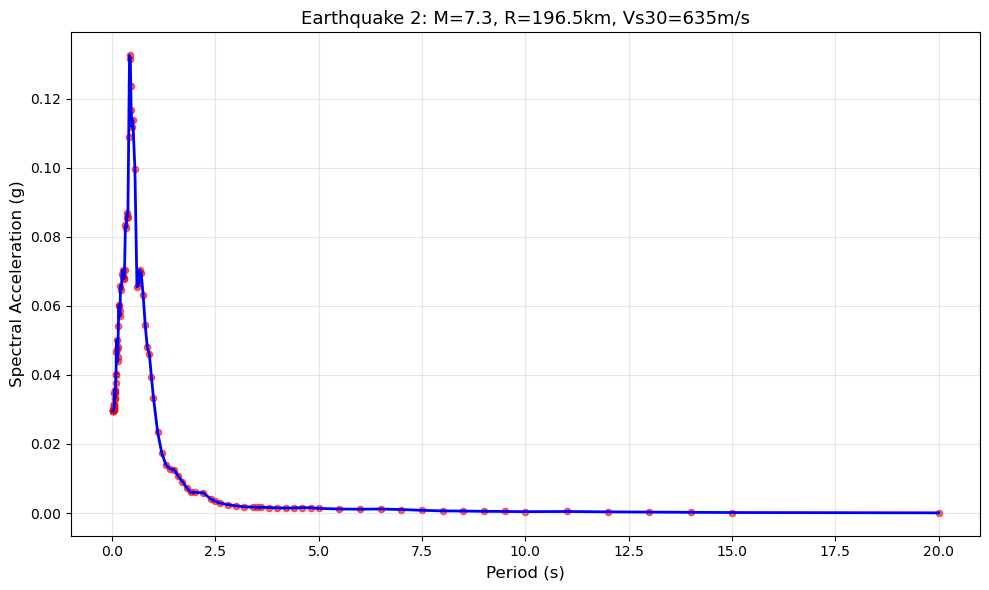

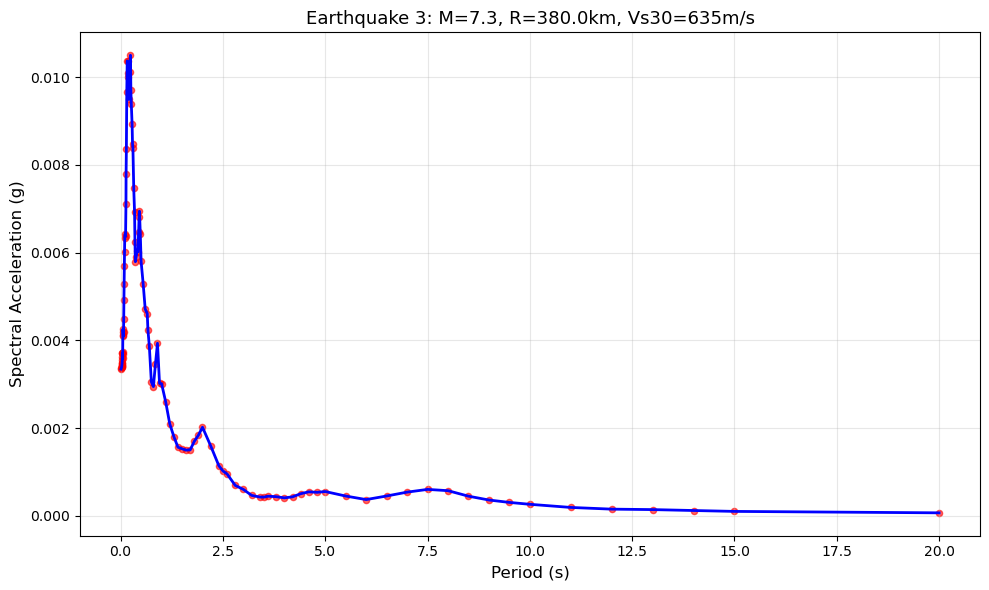

In [6]:
# Plot response spectra for 3 earthquakes
for i in range(3):
    plt.figure(figsize=(10, 6))
    
    # Get spectral values for this earthquake
    sa_values = df.iloc[i][period_cols_sorted].values
    
    # Get earthquake info
    mag = df.iloc[i]['Earthquake_Magnitude']
    dist = df.iloc[i]['Rjb_km']
    vs30 = df.iloc[i]['Vs30_Selected_for_Analysis_m_s']
    
    plt.plot(periods_sorted, sa_values, 'b-', linewidth=2)
    plt.scatter(periods_sorted, sa_values, c='red', s=20, alpha=0.6)
    
    plt.xlabel('Period (s)', fontsize=12)
    plt.ylabel('Spectral Acceleration (g)', fontsize=12)
    plt.title(f'Earthquake {i+1}: M={mag:.1f}, R={dist:.1f}km, Vs30={vs30:.0f}m/s', fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Earth_Magnitude vs PSA (T0pt010S)

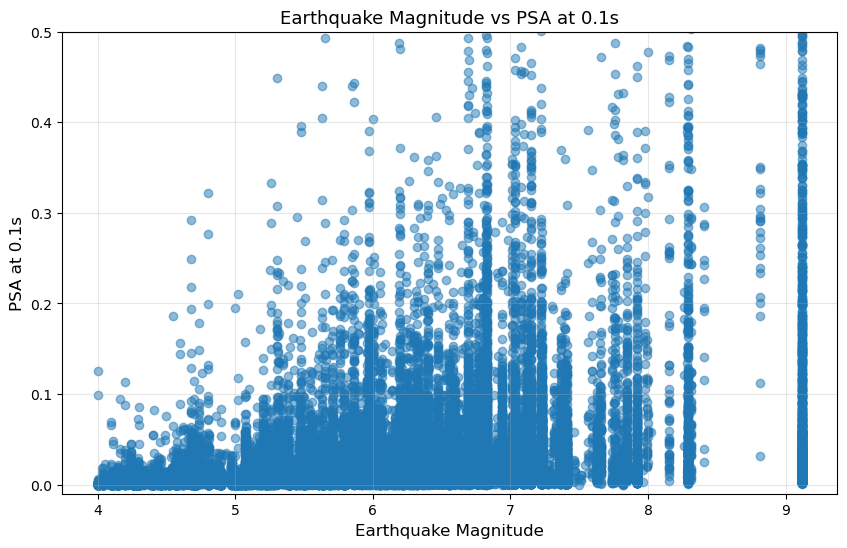

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Earthquake_Magnitude'], df['T0pt010S'], alpha=0.5)
plt.xlabel('Earthquake Magnitude', fontsize=12)
plt.ylabel('PSA at 0.1s', fontsize=12)
plt.title('Earthquake Magnitude vs PSA at 0.1s', fontsize=13)
plt.ylim(-0.01, 0.5)
plt.grid(True, alpha=0.3)
plt.show()

# Rupture (Rjb_km) vs PSA (T0pt010S)

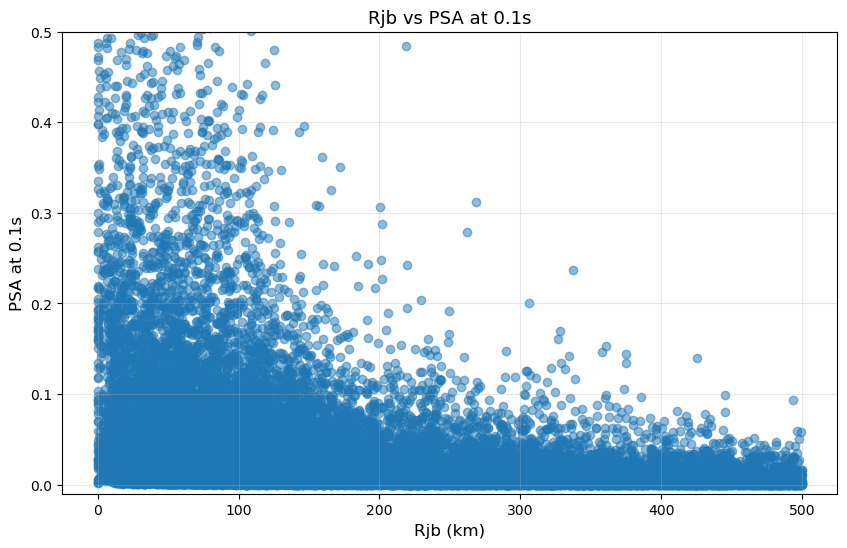

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Rjb_km'], df['T0pt010S'], alpha=0.5)
plt.xlabel('Rjb (km)', fontsize=12)
plt.ylabel('PSA at 0.1s', fontsize=12)
plt.title('Rjb vs PSA at 0.1s', fontsize=13)
plt.ylim(-0.01, 0.5)
plt.grid(True, alpha=0.3)
plt.show()

# Velocity (Vs30_Selected_for_Analysis_m_s) vs PSA (T0pt010S)

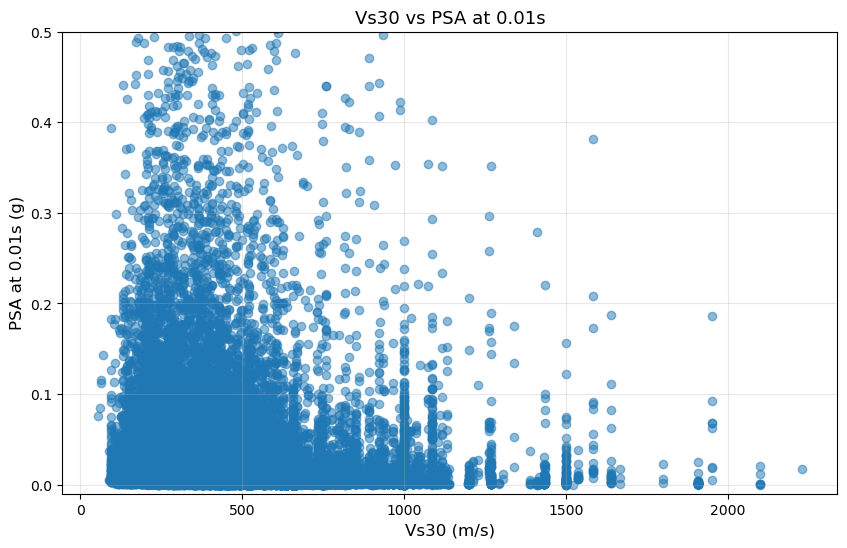

In [9]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Vs30_Selected_for_Analysis_m_s'], df['T0pt010S'], alpha=0.5)
plt.xlabel('Vs30 (m/s)', fontsize=12)
plt.ylabel('PSA at 0.01s (g)', fontsize=12)
plt.title('Vs30 vs PSA at 0.01s', fontsize=13)
plt.ylim(-0.01, 0.5)
plt.grid(True, alpha=0.3)
plt.show()

# Fitting a Linear Regression Model

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [23]:
# Prepare data for GMPE model - Add realistic filters
df_model = df[(df['Rjb_km'] > 0) & 
              (df['Vs30_Selected_for_Analysis_m_s'] > 0) &
              (df['PGA_g'] > 0) & (df['PGA_g'] < 5) &  # PGA typically 0-5g
              (df['T0pt010S'] > 0) & (df['T0pt010S'] < 5)].copy()  # PSA typically 0-5g

print(f"Data after realistic filtering: {df_model.shape}")

# Create features: M, log_R, log_Vs, Fault_Type
df_model['log_R'] = np.log(df_model['Rjb_km'])
df_model['log_Vs'] = np.log(df_model['Vs30_Selected_for_Analysis_m_s'])

# GMPE models predict log of ground motion (standard practice)
df_model['log_PGA'] = np.log(df_model['PGA_g'])
df_model['log_PSA'] = np.log(df_model['T0pt010S'])

X = df_model[['Earthquake_Magnitude', 'log_R', 'log_Vs', 'Fault_Type']].values
y_PGA = df_model['log_PGA'].values  # Predict log(PGA)
y_PSA = df_model['log_PSA'].values  # Predict log(PSA)

print(f"Features shape: {X.shape}")
print(f"log(PGA) range: {y_PGA.min():.4f} to {y_PGA.max():.4f}")
print(f"log(PSA) range: {y_PSA.min():.4f} to {y_PSA.max():.4f}")

Data after realistic filtering: (54065, 116)
Features shape: (54065, 4)
log(PGA) range: -16.5202 to 0.9316
log(PSA) range: -16.5192 to 0.9478


In [24]:
# Train/test split
X_train, X_test, y_PGA_train, y_PGA_test = train_test_split(X, y_PGA, test_size=0.2, random_state=42)
_, _, y_PSA_train, y_PSA_test = train_test_split(X, y_PSA, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 43252
Testing samples: 10813


In [25]:
# Train Model 1: PGA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

model_PGA = LinearRegression()
model_PGA.fit(X_train, y_PGA_train)
y_PGA_pred = model_PGA.predict(X_test)

r2_PGA = r2_score(y_PGA_test, y_PGA_pred)
rmse_PGA = np.sqrt(mean_squared_error(y_PGA_test, y_PGA_pred))
mae_PGA = mean_absolute_error(y_PGA_test, y_PGA_pred)

print("="*60)
print("PGA MODEL PERFORMANCE")
print("="*60)
print(f"R²: {r2_PGA:.4f}")
print(f"RMSE: {rmse_PGA:.4f}")
print(f"MAE: {mae_PGA:.4f}")
print(f"\nCoefficients:")
print(f"  Magnitude: {model_PGA.coef_[0]:.4f}")
print(f"  log_R: {model_PGA.coef_[1]:.4f}")
print(f"  log_Vs: {model_PGA.coef_[2]:.4f}")
print(f"  Fault_Type: {model_PGA.coef_[3]:.4f}")
print(f"  Intercept: {model_PGA.intercept_:.4f}")

PGA MODEL PERFORMANCE
R²: 0.5866
RMSE: 1.0212
MAE: 0.7859

Coefficients:
  Magnitude: 1.0098
  log_R: -1.4089
  log_Vs: -0.5928
  Fault_Type: -0.0252
  Intercept: -0.4900


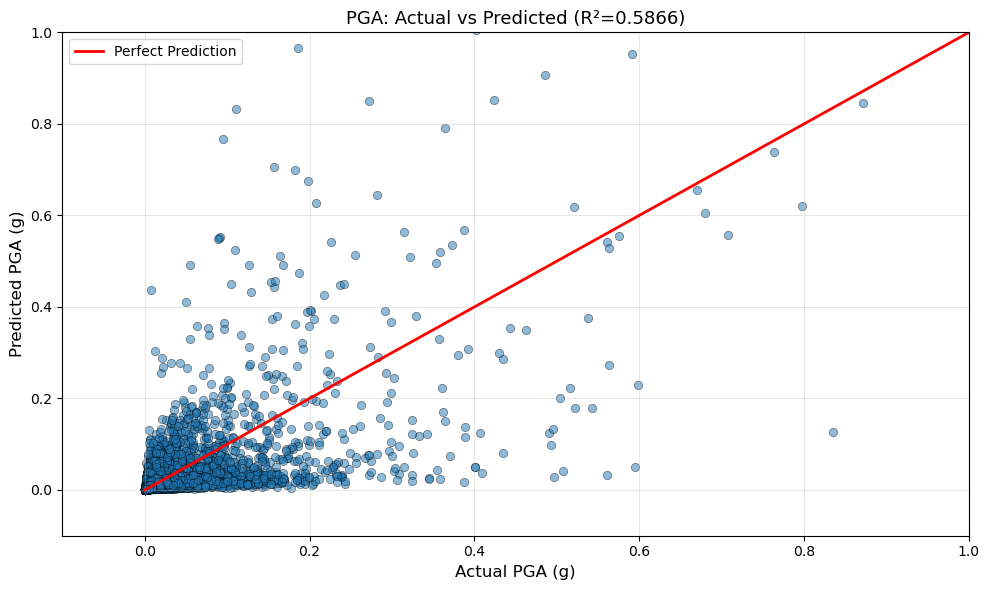

In [34]:
# Plot PGA: Actual vs Predicted
plt.figure(figsize=(10, 6))

# Convert back from log scale for visualization
y_PGA_test_linear = np.exp(y_PGA_test)
y_PGA_pred_linear = np.exp(y_PGA_pred)

plt.scatter(y_PGA_test_linear, y_PGA_pred_linear, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_PGA_test_linear.min(), y_PGA_test_linear.max()], 
         [y_PGA_test_linear.min(), y_PGA_test_linear.max()], 
         'r-', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual PGA (g)', fontsize=12)
plt.ylabel('Predicted PGA (g)', fontsize=12)
plt.title(f'PGA: Actual vs Predicted (R²={r2_PGA:.4f})', fontsize=13)
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Train Model 2: PSA at 0.01s
model_PSA = LinearRegression()
model_PSA.fit(X_train, y_PSA_train)
y_PSA_pred = model_PSA.predict(X_test)

r2_PSA = r2_score(y_PSA_test, y_PSA_pred)
rmse_PSA = np.sqrt(mean_squared_error(y_PSA_test, y_PSA_pred))
mae_PSA = mean_absolute_error(y_PSA_test, y_PSA_pred)

print("="*60)
print("PSA@0.01s MODEL PERFORMANCE")
print("="*60)
print(f"R²: {r2_PSA:.4f}")
print(f"RMSE: {rmse_PSA:.4f}")
print(f"MAE: {mae_PSA:.4f}")
print(f"\nCoefficients:")
print(f"  Magnitude: {model_PSA.coef_[0]:.4f}")
print(f"  log_R: {model_PSA.coef_[1]:.4f}")
print(f"  log_Vs: {model_PSA.coef_[2]:.4f}")
print(f"  Fault_Type: {model_PSA.coef_[3]:.4f}")
print(f"  Intercept: {model_PSA.intercept_:.4f}")

PSA@0.01s MODEL PERFORMANCE
R²: 0.5858
RMSE: 1.0226
MAE: 0.7872

Coefficients:
  Magnitude: 1.0088
  log_R: -1.4098
  log_Vs: -0.5893
  Fault_Type: -0.0258
  Intercept: -0.4929


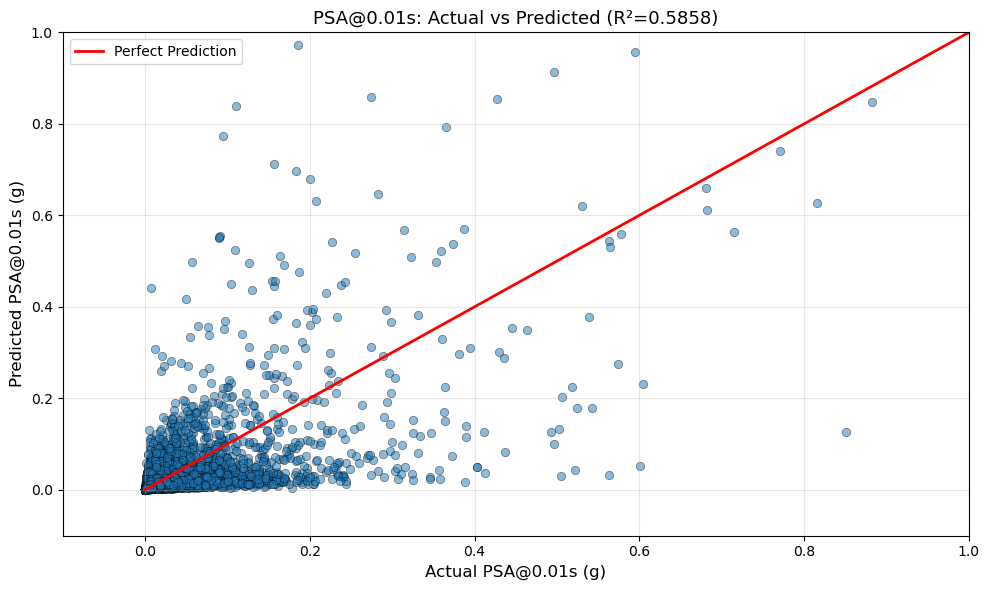

In [33]:
# Plot PSA: Actual vs Predicted
plt.figure(figsize=(10, 6))

# Convert back from log scale for visualization
y_PSA_test_linear = np.exp(y_PSA_test)
y_PSA_pred_linear = np.exp(y_PSA_pred)

plt.scatter(y_PSA_test_linear, y_PSA_pred_linear, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_PSA_test_linear.min(), y_PSA_test_linear.max()], 
         [y_PSA_test_linear.min(), y_PSA_test_linear.max()], 
         'r-', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual PSA@0.01s (g)', fontsize=12)
plt.ylabel('Predicted PSA@0.01s (g)', fontsize=12)
plt.title(f'PSA@0.01s: Actual vs Predicted (R²={r2_PSA:.4f})', fontsize=13)
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Artificial Neural Network (ANN) Model

In [35]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Standardize features for better ANN performance
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

print("ANN Model Architecture:")
print("  Hidden layers: (100, 50, 25)")
print("  Activation: ReLU")
print("  Solver: Adam")
print("  Max iterations: 500")
print("\nTraining ANN models...")

ANN Model Architecture:
  Hidden layers: (100, 50, 25)
  Activation: ReLU
  Solver: Adam
  Max iterations: 500

Training ANN models...


In [36]:
# Train ANN Model for PGA
ann_PGA = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=False,
    learning_rate_init=0.001,
    verbose=False
)

ann_PGA.fit(X_train_scaled, y_PGA_train)
y_PGA_pred_ann = ann_PGA.predict(X_test_scaled)

# Calculate metrics
r2_PGA_ann = r2_score(y_PGA_test, y_PGA_pred_ann)
rmse_PGA_ann = np.sqrt(mean_squared_error(y_PGA_test, y_PGA_pred_ann))
mae_PGA_ann = mean_absolute_error(y_PGA_test, y_PGA_pred_ann)

print("="*60)
print("ANN PGA MODEL PERFORMANCE")
print("="*60)
print(f"R²: {r2_PGA_ann:.4f}")
print(f"RMSE: {rmse_PGA_ann:.4f}")
print(f"MAE: {mae_PGA_ann:.4f}")
print(f"Number of iterations: {ann_PGA.n_iter_}")
print(f"Final loss: {ann_PGA.loss_:.6f}")

ANN PGA MODEL PERFORMANCE
R²: 0.7319
RMSE: 0.8224
MAE: 0.6375
Number of iterations: 193
Final loss: 0.312482


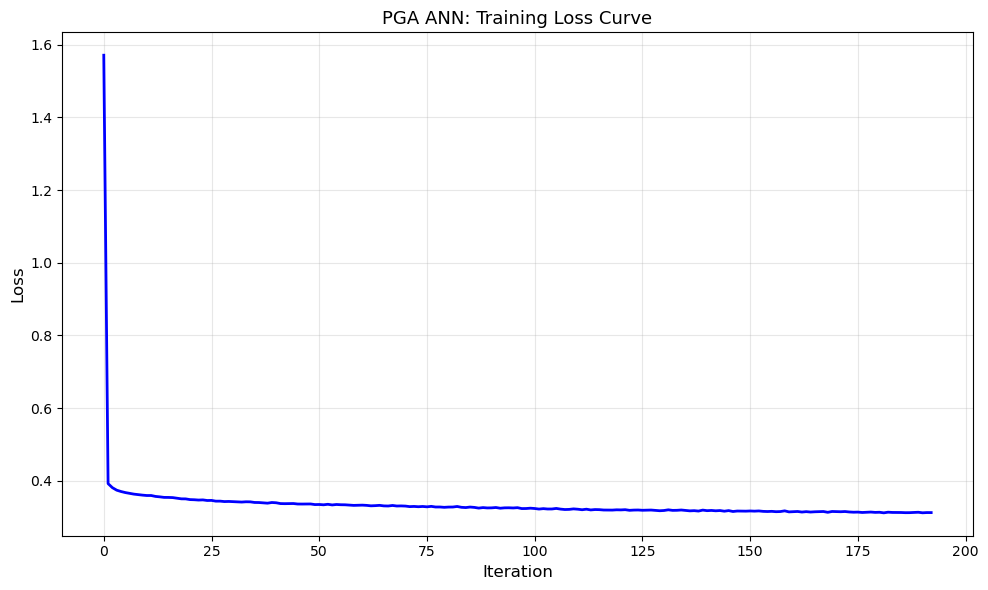

In [37]:
# Plot PGA ANN Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(ann_PGA.loss_curve_, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('PGA ANN: Training Loss Curve', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

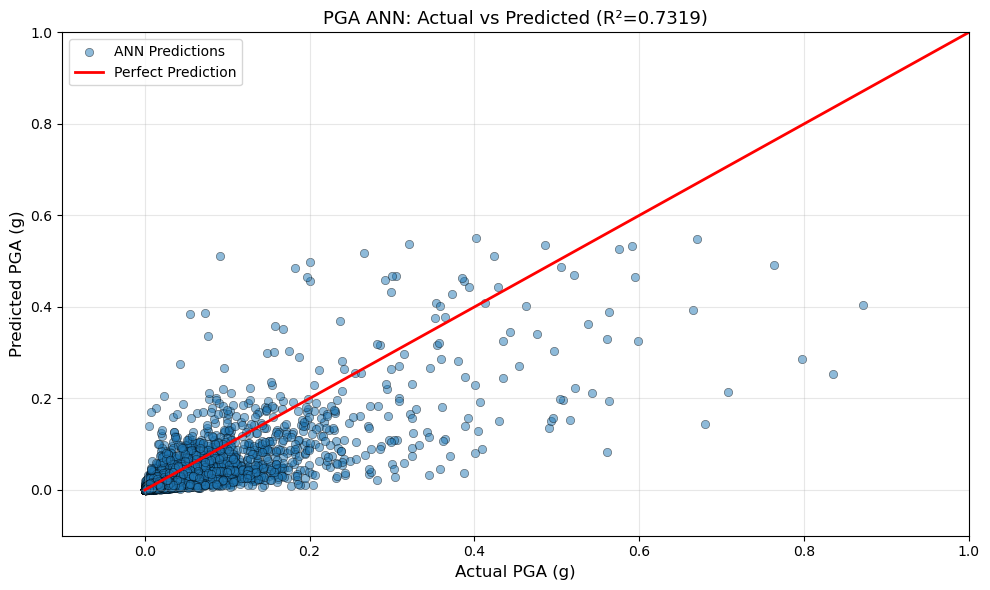

In [38]:
# Plot PGA ANN: Actual vs Predicted
plt.figure(figsize=(10, 6))

# Convert back from log scale for visualization
y_PGA_test_linear = np.exp(y_PGA_test)
y_PGA_pred_ann_linear = np.exp(y_PGA_pred_ann)

plt.scatter(y_PGA_test_linear, y_PGA_pred_ann_linear, alpha=0.5, edgecolors='k', linewidth=0.5, label='ANN Predictions')
plt.plot([y_PGA_test_linear.min(), y_PGA_test_linear.max()], 
         [y_PGA_test_linear.min(), y_PGA_test_linear.max()], 
         'r-', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual PGA (g)', fontsize=12)
plt.ylabel('Predicted PGA (g)', fontsize=12)
plt.title(f'PGA ANN: Actual vs Predicted (R²={r2_PGA_ann:.4f})', fontsize=13)
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Train ANN Model for PSA
ann_PSA = MLPRegressor(
    hidden_layer_sizes=(100, 50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=False,
    learning_rate_init=0.001,
    verbose=False
)

ann_PSA.fit(X_train_scaled, y_PSA_train)
y_PSA_pred_ann = ann_PSA.predict(X_test_scaled)

# Calculate metrics
r2_PSA_ann = r2_score(y_PSA_test, y_PSA_pred_ann)
rmse_PSA_ann = np.sqrt(mean_squared_error(y_PSA_test, y_PSA_pred_ann))
mae_PSA_ann = mean_absolute_error(y_PSA_test, y_PSA_pred_ann)

print("="*60)
print("ANN PSA@0.01s MODEL PERFORMANCE")
print("="*60)
print(f"R²: {r2_PSA_ann:.4f}")
print(f"RMSE: {rmse_PSA_ann:.4f}")
print(f"MAE: {mae_PSA_ann:.4f}")
print(f"Number of iterations: {ann_PSA.n_iter_}")
print(f"Final loss: {ann_PSA.loss_:.6f}")

ANN PSA@0.01s MODEL PERFORMANCE
R²: 0.7434
RMSE: 0.8048
MAE: 0.6217
Number of iterations: 314
Final loss: 0.302584


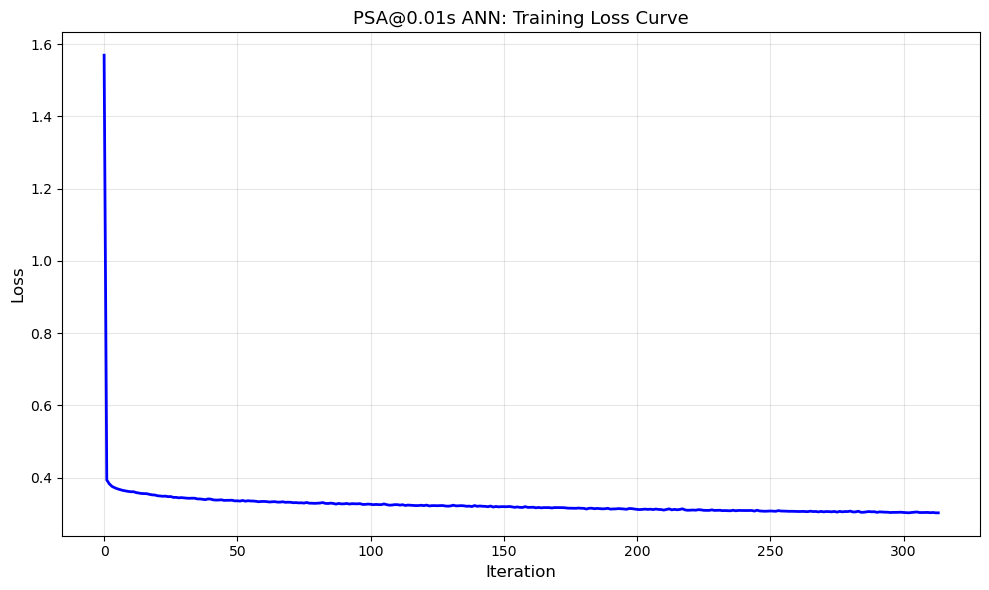

In [40]:
# Plot PSA ANN Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(ann_PSA.loss_curve_, 'b-', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('PSA@0.01s ANN: Training Loss Curve', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

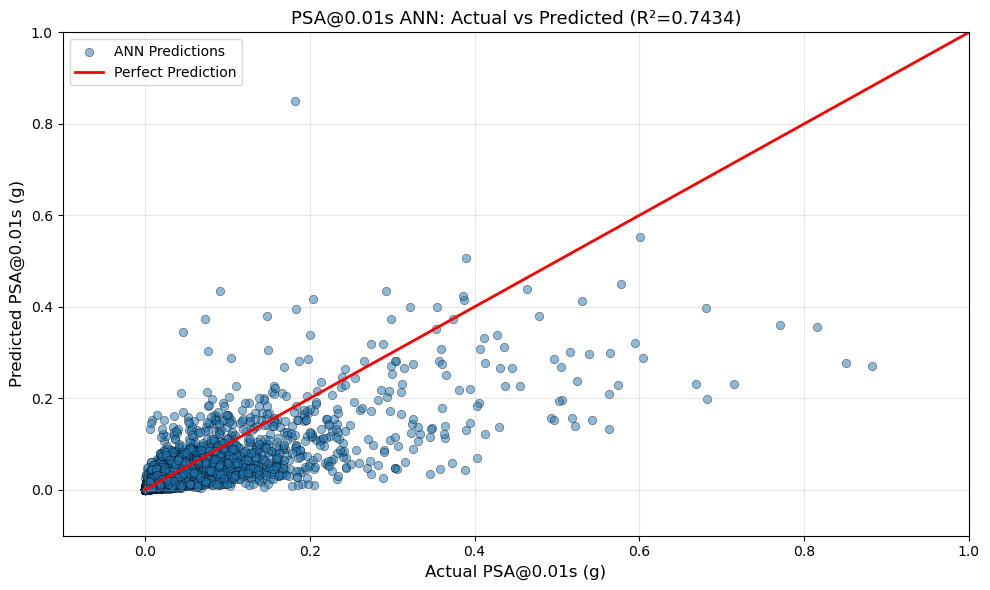

In [41]:
# Plot PSA ANN: Actual vs Predicted
plt.figure(figsize=(10, 6))

# Convert back from log scale for visualization
y_PSA_test_linear = np.exp(y_PSA_test)
y_PSA_pred_ann_linear = np.exp(y_PSA_pred_ann)

plt.scatter(y_PSA_test_linear, y_PSA_pred_ann_linear, alpha=0.5, edgecolors='k', linewidth=0.5, label='ANN Predictions')
plt.plot([y_PSA_test_linear.min(), y_PSA_test_linear.max()], 
         [y_PSA_test_linear.min(), y_PSA_test_linear.max()], 
         'r-', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual PSA@0.01s (g)', fontsize=12)
plt.ylabel('Predicted PSA@0.01s (g)', fontsize=12)
plt.title(f'PSA@0.01s ANN: Actual vs Predicted (R²={r2_PSA_ann:.4f})', fontsize=13)
plt.xlim(-0.1, 1)
plt.ylim(-0.1, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
# Compare Linear Regression vs ANN Performance
comparison_data = {
    'Model': ['Linear Regression', 'ANN', 'Linear Regression', 'ANN'],
    'Target': ['PGA', 'PGA', 'PSA@0.01s', 'PSA@0.01s'],
    'R²': [r2_PGA, r2_PGA_ann, r2_PSA, r2_PSA_ann],
    'RMSE': [rmse_PGA, rmse_PGA_ann, rmse_PSA, rmse_PSA_ann],
    'MAE': [mae_PGA, mae_PGA_ann, mae_PSA, mae_PSA_ann]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*70)
print("MODEL COMPARISON: Linear Regression vs ANN")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)


MODEL COMPARISON: Linear Regression vs ANN
            Model    Target       R²     RMSE      MAE
Linear Regression       PGA 0.586592 1.021244 0.785904
              ANN       PGA 0.731878 0.822443 0.637503
Linear Regression PSA@0.01s 0.585785 1.022625 0.787150
              ANN PSA@0.01s 0.743431 0.804833 0.621660
